# STEP 1 — Imports

In [2]:
import sys, os
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))

if ROOT not in sys.path:
    sys.path.append(ROOT)
    
import pandas as pd
from datasets import Dataset
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report, precision_recall_curve

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer
)

import numpy as np

/home/defalt/.pyenv/versions/venv-3.10.12/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# STEP 2 — Load Dataset

In [ ]:
# Path to your big preprocessed file
data_path = "../../datasets/processed/final_combined.csv"  # adjust if needed

df = pd.read_csv(data_path)

print(df.columns)
print(df.shape)

body_df = df.copy()

# Remove empty or missing body_text
body_df["body_text"] = body_df["body_text"].fillna("").astype(str)
body_df = body_df[body_df["body_text"].str.strip().astype(bool)]

# Remove lines if get bad results (part start)
# Remove overly short samples (noise cleaner)
body_df = body_df[body_df["body_text"].str.len() > 10]

# Remove duplicate body_text (prevents overfitting)
body_df = body_df.drop_duplicates(subset=["body_text"])

# Also clean HTML using your helper function (important)
# body_df["body_text"] = body_df["body_text"].apply(clean_html_simple)
# Remove till above lines if get bad results (part end)

# Keep only needed columns for this stage
body_df = body_df[["body_text", "label"]]

print("Body-only rows:", body_df.shape[0])
print(body_df["label"].value_counts(normalize=True))


/tmp/ipykernel_526302/719820720.py:4: DtypeWarning: Columns (3,4,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Index(['id', 'subject', 'body_text', 'attachment_text', 'headers_raw',
       'from_email', 'to_email', 'reply_to_email', 'date', 'urls',
       'header_from_reply_mismatch', 'header_domain_mismatch',
       'header_suspicious_tld', 'header_received_count', 'header_to_anomaly',
       'header_x_mailer_anomaly', 'header_date_malformed', 'label', 'source'],
      dtype='object')
(122339, 19)
Body-only rows: 82574
label
1    0.507533
0    0.492467
Name: proportion, dtype: float64


# STEP 3 — Train/Validation Split

In [12]:
train_df, val_df = train_test_split(
    body_df,
    test_size=0.2,
    random_state=42,
    stratify=body_df["label"],
)

print("Train:", train_df.shape, "Val:", val_df.shape)


Train: (66059, 2) Val: (16515, 2)


# STEP 4 — Build HuggingFace Datasets

In [13]:
train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))


# STEP 5 — Tokenizer (XLM-RoBERTa-large) and tokenize function

In [ ]:
model_name = "xlm-roberta-large"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

# For XLM-R, pad token is usually already defined (<pad>), but just in case:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    print("Assigned pad_token =", tokenizer.pad_token)

def tokenize_body(batch):
    return tokenizer(
        batch["body_text"],
        truncation=True,
        max_length=512,       # experiment with 256/512/768; chaning this needs to be changed in the evaluation function also
    )

train_ds_tokenized = train_ds.map(tokenize_body, batched=True, remove_columns=["body_text"])
val_ds_tokenized   = val_ds.map(tokenize_body,   batched=True, remove_columns=["body_text"])

Map: 100%|██████████| 16515/16515 [00:03<00:00, 4496.86 examples/s]


# STEP 6 — Data collator (dynamic padding)

In [16]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

# STEP 7 — Define Metrics

In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    cm = confusion_matrix(labels, preds)

    print("Confusion Matrix:")
    print(cm)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# STEP 8 — Load XLM-RoBERTa-large with stabilizing tricks

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", device)

model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2,
)

# Set pad token id in model config
model.config.pad_token_id = tokenizer.pad_token_id

# Gradient checkpointing for VRAM
model.gradient_checkpointing_enable()

model.to(device)


DEVICE: cuda


Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-large and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


XLMRobertaForSequenceClassification(
  (roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 1024, padding_idx=1)
      (position_embeddings): Embedding(514, 1024, padding_idx=1)
      (token_type_embeddings): Embedding(1, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-23): 24 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): XLMRobertaSelfOutput(
              (dense): Linear(in_features=1024, ou

# STEP 9 — TrainingArguments for Stage-2

In [9]:
training_args = TrainingArguments(
    output_dir="body_model_xlmr_large_out",

    eval_strategy="epoch",          # with your HF version this works
    save_strategy="epoch",

    learning_rate=1e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.06,

    per_device_train_batch_size=4,   # safe starting point; auto_find can increase
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,   # effective batch size = 16
    
    num_train_epochs=3,
    weight_decay=0.01,

    fp16=False,                     # mixed precision
    bf16=True,
    max_grad_norm=1.0,
    # auto_find_batch_size=True,    # let HF try to grow until OOM

    gradient_checkpointing=True,    # ties with model.gradient_checkpointing_enable()

    logging_steps=100,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",

    optim="adamw_torch",
    label_smoothing_factor=0.1,
    report_to="none",
)

# STEP 10 — Trainer & Training

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds_tokenized,
    eval_dataset=val_ds_tokenized,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

print("===== BODY MODEL VALIDATION METRICS =====")
metrics = trainer.evaluate()
for key, value in metrics.items():
    print(f"{key}: {value}")


df = pd.DataFrame(trainer.state.log_history)
eval_df = df[df["eval_loss"].notna()].copy()

if "epoch" not in eval_df.columns:
    eval_df["epoch"] = range(1, len(eval_df) + 1)

eval_df["epoch"] = eval_df["epoch"].astype(int)
print("Eval columns:", list(eval_df.columns))

df.head()

/tmp/ipykernel_197532/3859464242.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.212900,0.212626,0.994350,0.993211,0.995251,0.994230
2,0.209700,0.210074,0.994978,0.994105,0.995636,0.994870
3,0.207700,0.208330,0.995857,0.995383,0.996149,0.995766


Confusion Matrix:
[[8085   53]
 [  37 7754]]
Confusion Matrix:
[[8092   46]
 [  34 7757]]
Confusion Matrix:
[[8102   36]
 [  30 7761]]
===== BODY MODEL VALIDATION METRICS =====


Confusion Matrix:
[[8102   36]
 [  30 7761]]
{'eval_loss': 0.20833037793636322, 'eval_accuracy': 0.9958566137233976, 'eval_precision': 0.9953828395536745, 'eval_recall': 0.9961494031574895, 'eval_f1': 0.9957659738260201, 'eval_runtime': 342.5863, 'eval_samples_per_second': 46.496, 'eval_steps_per_second': 11.626, 'epoch': 3.0}
Eval columns: ['loss', 'grad_norm', 'learning_rate', 'epoch', 'step', 'eval_loss', 'eval_accuracy', 'eval_precision', 'eval_recall', 'eval_f1', 'eval_runtime', 'eval_samples_per_second', 'eval_steps_per_second', 'train_runtime', 'train_samples_per_second', 'train_steps_per_second', 'total_flos', 'train_loss']


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.6395,16.833937,0.000001,0.025111,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.4587,8.138994,0.000003,0.050223,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.2892,1.028866,0.000004,0.075334,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.2632,111.997177,0.000006,0.100446,400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.2604,49.484447,0.000007,0.125557,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# STEP 11 — Plot Train Loss Curve

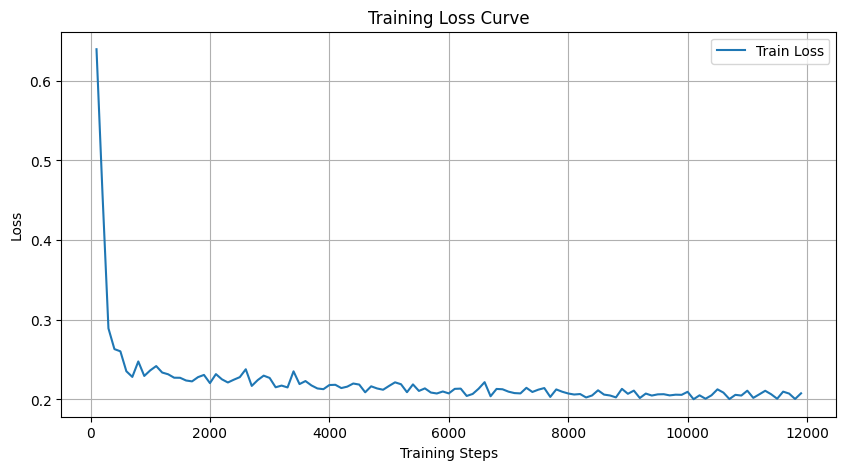

In [11]:
plt.figure(figsize=(10,5))
plt.plot(df[df["loss"].notna()]["step"], df[df["loss"].notna()]["loss"], label="Train Loss")
plt.xlabel("Training Steps")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid(True)
plt.show()

# STEP 12 — Plot Evaluation Metrics Per Epoch

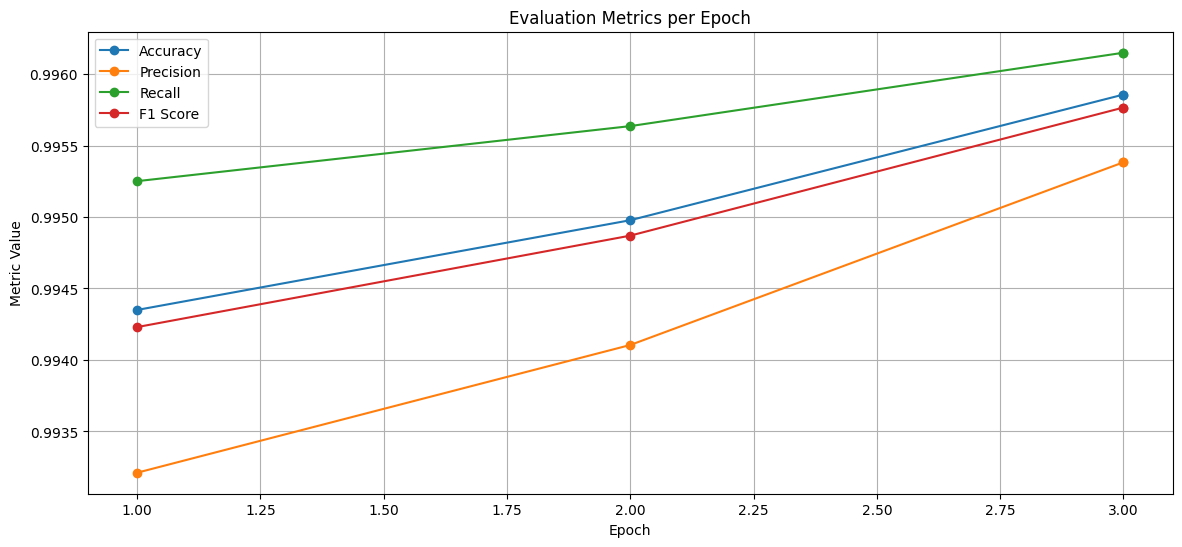

In [12]:
plt.figure(figsize=(14,6))

if "eval_accuracy" in eval_df:
    plt.plot(eval_df["epoch"], eval_df["eval_accuracy"], marker="o", label="Accuracy")

if "eval_precision" in eval_df:
    plt.plot(eval_df["epoch"], eval_df["eval_precision"], marker="o", label="Precision")

if "eval_recall" in eval_df:
    plt.plot(eval_df["epoch"], eval_df["eval_recall"], marker="o", label="Recall")

if "eval_f1" in eval_df:
    plt.plot(eval_df["epoch"], eval_df["eval_f1"], marker="o", label="F1 Score")
    
plt.xlabel("Epoch")
plt.ylabel("Metric Value")
plt.title("Evaluation Metrics per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# STEP 13 — Confusion Matrix for body model

Confusion Matrix:
[[8102   36]
 [  30 7761]]


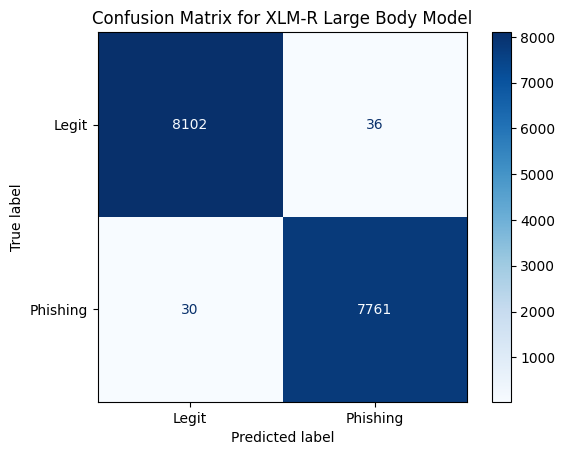

In [14]:
predictions = trainer.predict(val_ds_tokenized)
y_true = predictions.label_ids
y_pred = predictions.predictions.argmax(-1)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legit", "Phishing"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix for XLM-R Large Body Model")
plt.show()

# STEP 14 — Classification Report

In [15]:
print(classification_report(y_true, y_pred, target_names=["Legit", "Phishing"]))

              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      8138
    Phishing       1.00      1.00      1.00      7791

    accuracy                           1.00     15929
   macro avg       1.00      1.00      1.00     15929
weighted avg       1.00      1.00      1.00     15929



# STEP 15 — Precision–Recall Curve (For imbalanced phishing data)

Confusion Matrix:
[[8102   36]
 [  30 7761]]


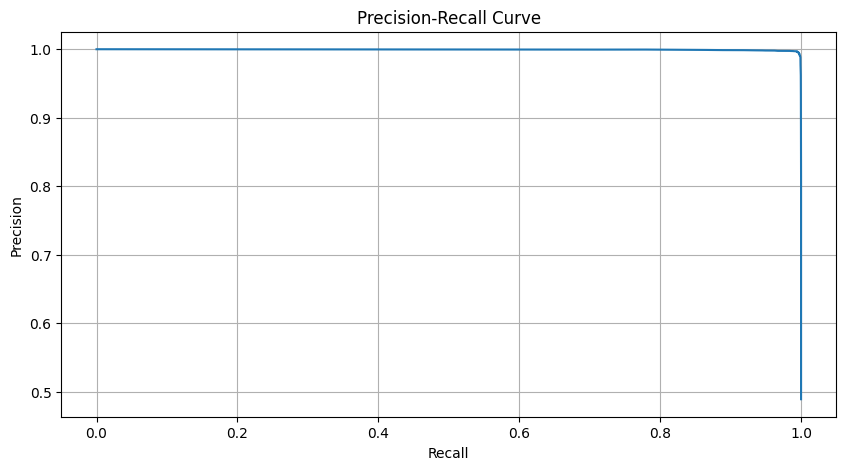

In [ ]:
y_true = predictions.label_ids
y_probs = torch.softmax(torch.tensor(predictions.predictions), dim=1)[:, 1]  # phishing probability
y_probs = y_probs.numpy()

prec, rec, thresh = precision_recall_curve(y_true, y_probs)

plt.figure(figsize=(10,5))
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

# STEP 16 — Save Model + Tokenizer

In [ ]:
# trainer.save_model("body_encoder_xlmr_large")
# tokenizer.save_pretrained("body_encoder_xlmr_large_tokenizer")

# print("Training complete and model saved.")

Training complete and model saved.


# STEP 17 — Test model with user input

In [ ]:
def predict_body(text: str) -> str:
    model.eval()
    encoded = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=512,         # change from tokenizer function
        return_tensors="pt",
    )
    encoded = {k: v.to(model.device) for k, v in encoded.items()}

    with torch.no_grad():
        output = model(**encoded)
        pred = torch.argmax(output.logits, dim=1).item()

    return "🔴 PHISHING (body)" if pred == 1 else "🟢 LEGITIMATE (body)"

# Example:
while True:
    text = input("Email body: ")
    if text.lower() in ['b', 'break']:
        break
    print(predict_body(text))


NameError: name 'model' is not defined

# Load Saved Model and Evaluate (Inference)

In [4]:
MODEL_DIR = "body_encoder_xlmr_large"
TOKENIZER_DIR = "body_encoder_xlmr_large_tokenizer"

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load tokenizer + model
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_DIR)
model.to(device)
model.eval()

MAX_LEN = 512

def predict_text(text: str):
    # Tokenize
    inputs = tokenizer(
        [text],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
        return_tensors="pt"
    ).to(device)

    # Inference
    with torch.no_grad():
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        pred = int(np.argmax(probs))

    return {
        "predicted_label": "🔴 PHISHING (body)" if pred == 1 else "🟢 LEGITIMATE (body)",
        "prob_legit": float(probs[0]),
        "prob_phishing": float(probs[1]),
        "raw_probs": probs.tolist()
    }

# Example
while True:
    text = input("Email body: ")
    if text.lower() in ['b', 'break']:
        break
    print(predict_body(text))

OutOfMemoryError: CUDA out of memory. Tried to allocate 978.00 MiB. GPU 0 has a total capacity of 11.63 GiB of which 155.62 MiB is free. Process 26716 has 5.04 GiB memory in use. Process 62346 has 4.39 GiB memory in use. Including non-PyTorch memory, this process has 1.47 GiB memory in use. Of the allocated memory 1.36 GiB is allocated by PyTorch, and 4.96 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)